# Image processing

In [1]:
import cv2
import os
import matplotlib.pyplot as plt
import numpy as np
import glob

In [2]:
VIDEO_FILE = "baile_pendulo.mp4"

cap = cv2.VideoCapture(VIDEO_FILE)
if not cap.isOpened():
    raise FileNotFoundError(f"Could not open video: {VIDEO_FILE}")

fps = cap.get(cv2.CAP_PROP_FPS) or 30
# Display period stays fixed; speed is controlled by how fast virtual_pos advances
delay = max(1, int(1000 / fps))

# Bootstrap: pre-read first two source frames
ret, frame_a = cap.read()
if not ret:
    cap.release()
    raise RuntimeError("Video is empty")

ret, frame_b = cap.read()
if not ret:
    frame_b = None

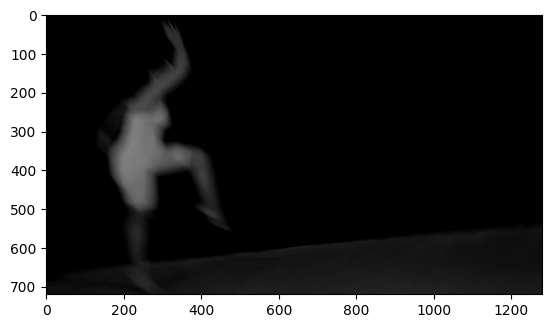

In [130]:
ret, frame = cap.read()
if not ret:
    frame = None

img_rgb = cv2.cvtColor(frame,cv2.COLOR_BGR2RGB)

plt.figure()
plt.imshow(img_rgb)

In [131]:
# Save frame as PNG for testing
cv2.imwrite("frame.png", frame)

True

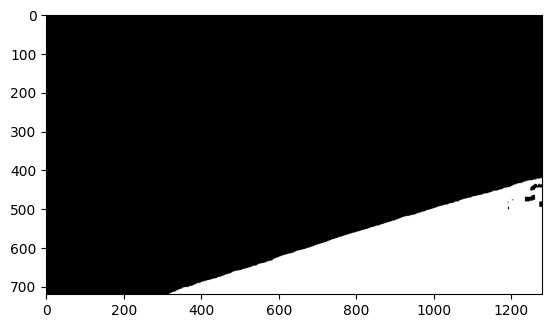

In [34]:
img_gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)
img_bin  = cv2.threshold(img_gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)[1]

plt.figure()
plt.imshow(img_bin, cmap="gray")

In [2]:
"""
Estimate the angle of the line separating a black region from a white region
in an image (or a sequence of images), and track how that angle changes.

How it works
------------
1. Load the image and convert to grayscale.
2. Threshold it into a binary mask (black = 0, white = 255).
3. For each column in the image, find the row where the mask transitions
   from black to white (the boundary point for that column).
4. Fit a straight line (least-squares) to all the boundary points.
5. Convert the line's slope into an angle in degrees.

Angle convention: 0 degrees = perfectly horizontal line. Positive angle means
the line tilts so that it goes up (in image terms, y decreases) as x
increases; negative means it tilts down. Adjust the sign convention in
`slope_to_angle` if you want a different reference.
"""


def find_boundary_points(binary_mask: np.ndarray) -> np.ndarray:
    """
    For each column, find the y-coordinate of the black->white transition.

    binary_mask: 2D array, values 0 (black) or 255 (white).
    Returns an (N, 2) array of (x, y) boundary points, one per column that
    has a clear transition.
    """
    h, w = binary_mask.shape
    points = []

    for x in range(w):
        col = binary_mask[:, x]
        white_rows = np.where(col == 255)[0]
        if white_rows.size == 0:
            continue  # column is all black, no boundary
        # The boundary is the first white pixel going down the column
        y = white_rows[0]
        points.append((x, y))

    return np.array(points)


def slope_to_angle(vx: float, vy: float) -> float:
    """
    Convert a direction vector (vx, vy) from cv2.fitLine into an angle in
    degrees, measured from the horizontal axis.
    """
    angle_rad = np.arctan2(-vy, vx)  # negative vy: image y grows downward
    angle_deg = np.degrees(angle_rad)

    # Normalize to the range (-90, 90] since a line has no direction (only
    # orientation) -- a line at 100 degrees is the same as one at -80.
    if angle_deg > 90:
        angle_deg -= 180
    elif angle_deg <= -90:
        angle_deg += 180

    return angle_deg


def estimate_line_angle(image_path: str, threshold: int = 127, debug_path: str = None):
    """
    Load an image, find the black/white boundary, fit a line, and return
    the angle in degrees along with the fitted line parameters.
    """
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise FileNotFoundError(f"Could not read image: {image_path}")

    _, binary = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    points = find_boundary_points(binary)
    if len(points) < 2:
        raise ValueError(f"Not enough boundary points found in {image_path}")

    points = points.astype(np.float32)

    # cv2.fitLine does a robust least-squares fit: returns (vx, vy, x0, y0)
    vx, vy, x0, y0 = cv2.fitLine(points, cv2.DIST_L2, 0, 0.01, 0.01).flatten()

    angle = slope_to_angle(vx, vy)

    if debug_path:
        color = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
        h, w = img.shape
        # Draw the fitted line across the full image width
        t = w  # arbitrary large scale
        pt1 = (int(x0 - vx * t), int(y0 - vy * t))
        pt2 = (int(x0 + vx * t), int(y0 + vy * t))
        cv2.line(color, pt1, pt2, (0, 0, 255), 2)
        for (px, py) in points[::10]:  # sample every 10th point for clarity
            cv2.circle(color, (int(px), int(py)), 2, (0, 255, 0), -1)
        cv2.imwrite(debug_path, color)

    return angle, (vx, vy, x0, y0)

def estimate_floor_angle(img_gray: np.ndarray, debug: bool = False):
    """
    Detect the floor/stage edge using Canny + HoughLinesP, after masking
    out the bright person silhouette so person edges don't interfere.
    Returns (angle_deg, (x1, y1, x2, y2)) for the dominant line.
    """
    h, w = img_gray.shape

    # Build a person mask and dilate it so the person's own edges are excluded
    _, person_mask = cv2.threshold(img_gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    kernel = np.ones((40, 40), np.uint8)
    person_mask_dilated = cv2.dilate(person_mask, kernel)

    # Canny on the original grayscale (lower thresholds to catch the faint floor edge)
    edges = cv2.Canny(img_gray, 15, 50)

    # Remove person area from edges
    edges_floor = cv2.bitwise_and(edges, cv2.bitwise_not(person_mask_dilated))

    # Detect line segments — minLineLength keeps only long lines (floor edge)
    lines = cv2.HoughLinesP(edges_floor, 1, np.pi / 180,
                             threshold=20, minLineLength=w // 6, maxLineGap=60)
    if lines is None:
        raise ValueError("No floor line detected")

    # Pick the longest segment
    best = max(lines, key=lambda l: np.hypot(l[0][2] - l[0][0], l[0][3] - l[0][1]))[0]
    x1, y1, x2, y2 = best

    angle_deg = np.degrees(np.arctan2(-(y2 - y1), x2 - x1))
    if angle_deg > 90:    angle_deg -= 180
    elif angle_deg <= -90: angle_deg += 180

    if debug:
        vis = cv2.cvtColor(img_gray, cv2.COLOR_GRAY2BGR)
        # show all candidate segments in blue
        for seg in lines:
            sx1, sy1, sx2, sy2 = seg[0]
            cv2.line(vis, (sx1, sy1), (sx2, sy2), (200, 100, 0), 1)
        # highlight the winner in red
        cv2.line(vis, (x1, y1), (x2, y2), (0, 0, 255), 3)
        plt.figure(figsize=(12, 5))
        plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
        plt.title(f"Floor edge  {angle_deg:.1f}°")
        plt.show()

    return angle_deg, (x1, y1, x2, y2)



In [35]:
angle, _ = estimate_line_angle("frame.png", debug_path="debug_001.png")
print(f"Angle: {angle:.2f} degrees")

Angle: 17.31 degrees


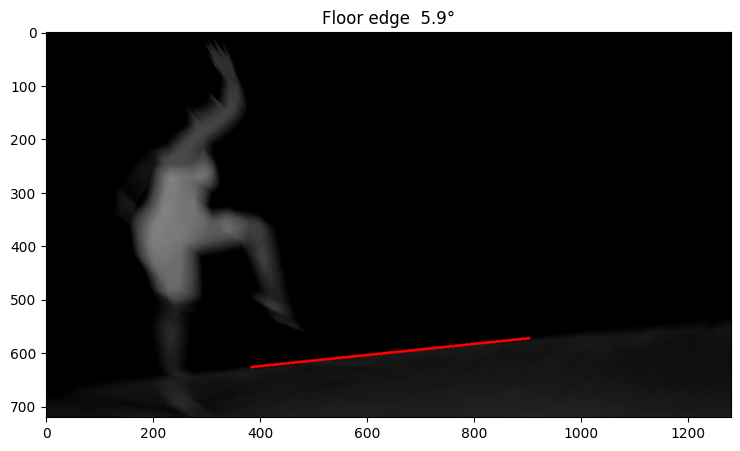

Floor angle: 5.93°


In [135]:
angle, line = estimate_floor_angle(img_gray, debug=True)
print(f"Floor angle: {angle:.2f}°")


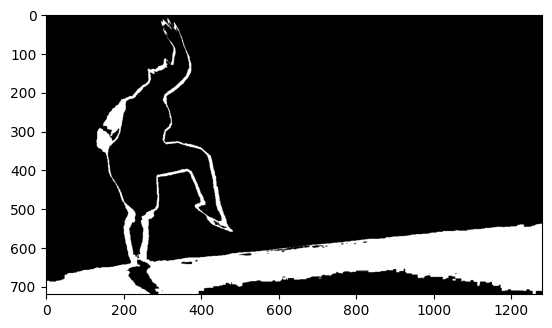

In [32]:
img_bgr = cv2.imread("frame.png")
# img_bgr to grayscale
img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
# fix upper and lower threshold without Otsu
lower_thresh, upper_thresh = 5, 25
img_thresh  = cv2.threshold(img_gray, upper_thresh, 255, cv2.THRESH_TOZERO_INV)[1]
img_bin = cv2.threshold(img_thresh, lower_thresh, 255, cv2.THRESH_BINARY)[1]

plt.figure()
plt.imshow(img_bin, cmap="gray")

In [18]:
img_bin.max()

255